<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1945 | Val: 472 | Test: 90


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 14, accumulation steps = 1 (effective batch size ≈ 14, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 1.0497 acc 0.553 | val loss 0.7314 acc 0.631 *


[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 0.7907 acc 0.669 | val loss 0.6139 acc 0.748 *


[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.7201 acc 0.717 | val loss 0.7047 acc 0.720


[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.6537 acc 0.729 | val loss 0.6066 acc 0.780 *


[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.5814 acc 0.756 | val loss 0.6882 acc 0.803


...

[DenseNet-121] Epoch  20/100 | LR: 2.74e-06 | train loss 0.1379 acc 0.939 | val loss 0.3466 acc 0.873


[DenseNet-121] Epoch  21/100 | LR: 2.74e-07 | train loss 0.1582 acc 0.935 | val loss 0.3538 acc 0.877


[DenseNet-121] Epoch  22/100 | LR: 2.74e-07 | train loss 0.1472 acc 0.935 | val loss 0.3614 acc 0.875


[DenseNet-121] Epoch  23/100 | LR: 2.74e-07 | train loss 0.1519 acc 0.929 | val loss 0.3578 acc 0.883


[DenseNet-121] Epoch  24/100 | LR: 2.74e-07 | train loss 0.1495 acc 0.932 | val loss 0.3462 acc 0.875

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 24.

[DenseNet-121] Restored best checkpoint (val loss = 0.3268)


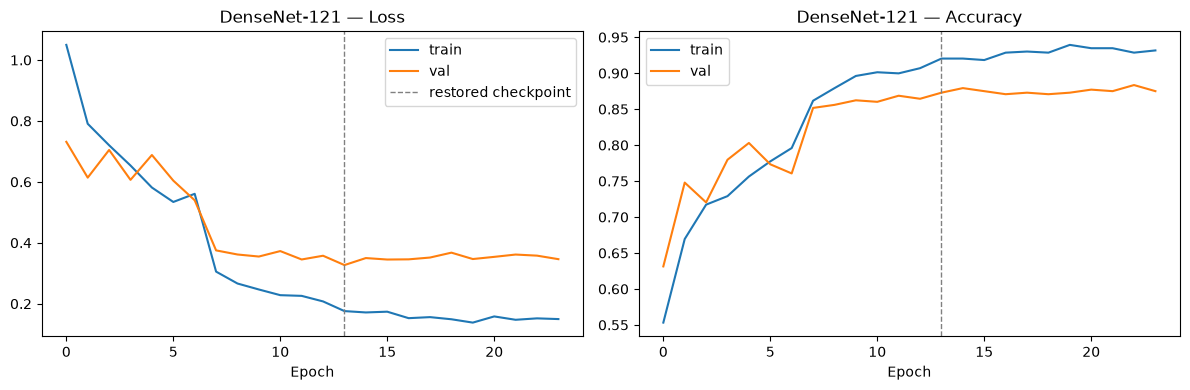

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.867


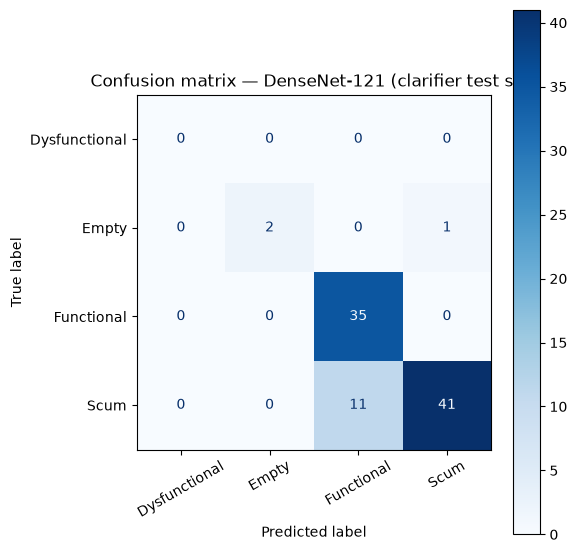

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000         0
        Empty      1.000     0.667     0.800         3
   Functional      0.761     1.000     0.864        35
         Scum      0.976     0.788     0.872        52

     accuracy                          0.867        90
    macro avg      0.684     0.614     0.634        90
 weighted avg      0.893     0.867     0.867        90

  [warn] 'Dysfunctional' has 0 examples in this test set — AUC undefined, skipping.


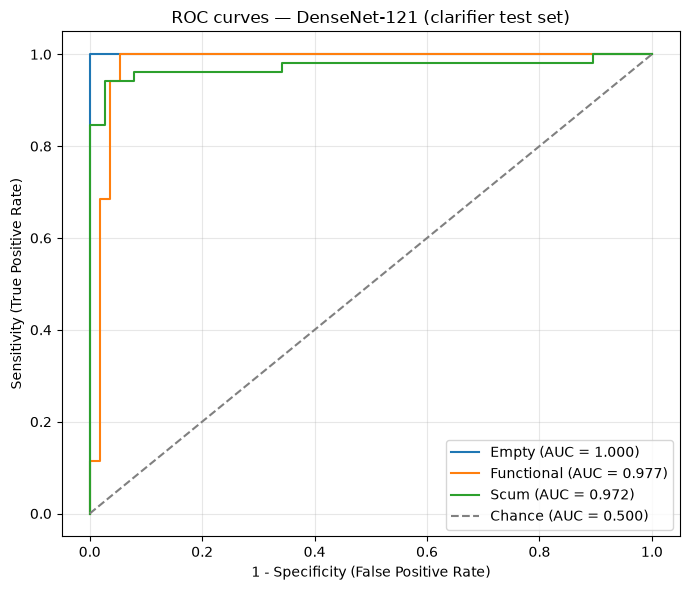

AUC (area under ROC curve) per class:
  Dysfunctional  : undefined (0 examples)
  Empty          : 1.000
  Functional     : 0.977
  Scum           : 0.972

Mean AUC (over 3/4 classes with test examples): 0.983


(np.float64(0.8666666666666667),
 {'Dysfunctional': nan,
  'Empty': 1.0,
  'Functional': 0.9771428571428571,
  'Scum': 0.9721659919028339})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_Atlantis.pkl


Saved model weights to ../models/clarifier_densenet121_cnn.pt
